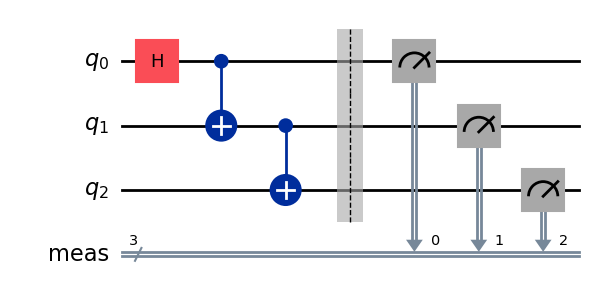

In [6]:
from qiskit import QuantumCircuit

def create_ghz_circuit(qc):
    # please implement your circuit here.
    # useful tutorials
    #  https://docs.quantum.ibm.com/build/circuit-construction
    # your code here
    qc.h(0)
    qc.cx(0, 1)
    qc.cx(1, 2)
    #raise NotImplementedError
    
qc = QuantumCircuit(3) # create a quantum circuit with three qubits
create_ghz_circuit(qc) # call the code created by the student to populate the gates in the circuit
qc.measure_all() # measure the outputs
qc.draw('mpl', style="iqp") # draw the circuit

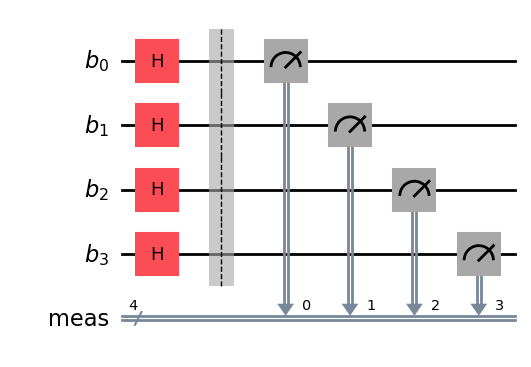

In [66]:
from qiskit import QuantumCircuit, QuantumRegister
from numpy import pi

def mark_pure_states(qc, b0 , b1, b2, b3):
    # mark the components corresponding to the pure states |0011> , |1100>, |0101>
    # your code here
    #for i in range(4):
    #    qc.h(i)
    if b0 == 0 and b1 == 0 and b2 == 1 and b3 == 1:
        qc.x(0)
        qc.x(1)
    elif b0 == 1 and b1 == 1 and b2 == 0 and b3 == 0:
        qc.x(2)
        qc.x(3)
    elif b0 == 0 and b1 == 1 and b2 == 0 and b3 == 1:
        qc.x(0)
        qc.x(2)
    #raise NotImplementedError
    
b = QuantumRegister(4, 'b')
qc = QuantumCircuit(b)
mark_pure_states(qc, b[0], b[1], b[2], b[3])
qc.measure_all() # measure the outputs
qc.draw('mpl', style='iqp')

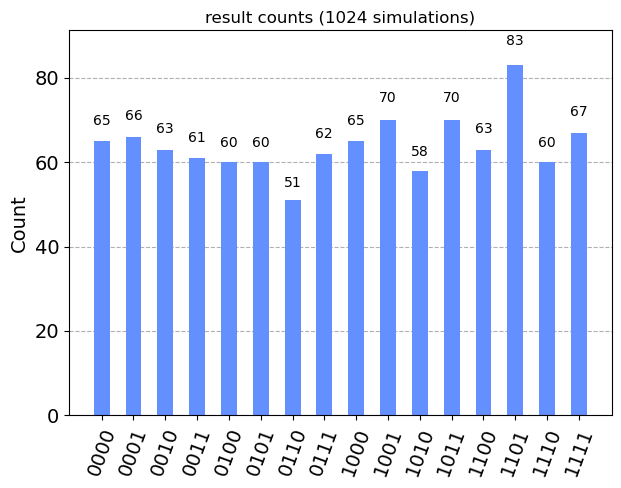

In [67]:
from qiskit import transpile 
#from qiskit import Aer
#from qiskit_aer import Aer
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

simulator = AerSimulator()
circ = transpile(qc, simulator)
# Run and get counts
result = simulator.run(circ).result()
counts = result.get_counts(circ)
plot_histogram(counts, title='result counts (1024 simulations)')

In [89]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator

simulator = AerSimulator()

circuit = QuantumCircuit(2)
circuit.h(0)
circuit.save_statevector('psi1')
circuit.cx(0, 1)
circuit.save_statevector('psi2')

result = simulator.run(transpile(circuit, simulator)).result()
data = result.data()

psi1 = data['psi1']
psi2 = data['psi2']

#print(result.get_statevector())

#state_vector = result.get_statevector()
#print(state_vector)

display(psi1.draw(output = 'latex'))
display(psi2.draw(output = 'latex'))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [80]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from numpy import pi

simulator = AerSimulator()

circuit = QuantumCircuit(4)
circuit.x(0)
circuit.x(1)
circuit.mcp(pi, [0,1,2], 3)
circuit.save_statevector('psi1')
circuit.x(0)
circuit.x(1)

circuit.x(2)
circuit.x(3)
circuit.save_statevector('psi2')
circuit.x(2)
circuit.x(3)

result = simulator.run(transpile(circuit, simulator)).result()
data = result.data()

psi1 = data['psi1']
psi2 = data['psi2']

display(psi1.draw(output = 'latex'))
display(psi2.draw(output = 'latex'))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>